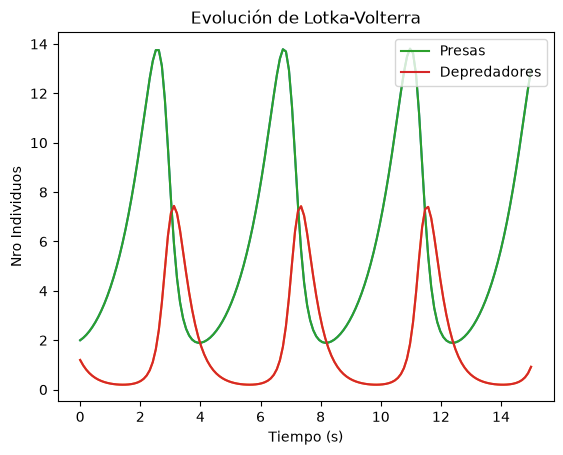

In [443]:
# SIMULACION DE LOTKA-VOLTERRA CON RK4
import numpy as np
import matplotlib.pyplot as plt

Nt = 150
T = 15.0
time = np.linspace(0, T, Nt)
dt = time[1] - time[0]

def F(x0, params):
    x = np.zeros((Nt, 2))
    x[0] = x0

    def f(x):
        alpha, beta, delta, gamma = params
        x1, x2 = x
        dx1dt = alpha * x1 - beta * x1 * x2
        dx2dt = delta * x1 * x2 - gamma * x2
        return np.array([dx1dt, dx2dt])
    
    for k in range(Nt-1):
        x1, x2 = x[k]
        k1 = f(x[k])
        k2 = f(x[k] + 0.5 * dt * k1)
        k3 = f(x[k] + 0.5 * dt * k2)
        k4 = f(x[k] + dt * k3)
        x[k+1] = x[k] + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x

alpha = 1.0
beta = 0.5
delta = 0.5
gamma = 3.0
x0 = [2.0, 1.2]
params = [alpha, beta, delta, gamma]
x = F(x0, params)
plt.plot(time, x)

plt.plot(time, x[:,0], label="Presas")
plt.plot(time, x[:,1], label="Depredadores")
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Evolución de Lotka-Volterra")
plt.legend(loc="upper right")
plt.show()

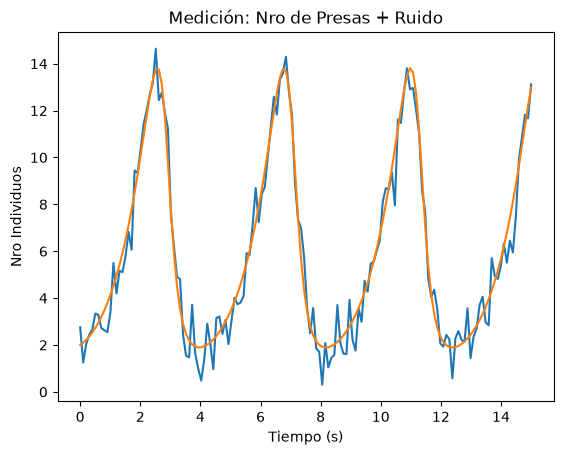

In [444]:
# SIMULAR OBSERVACIÓN DE X1 (PRESAS) CON RUIDO
X_real = np.copy(x)
sigma = 0.25
dW = np.random.normal(0, np.sqrt(dt), Nt)

dY = X_real[:, 0] * dt + sigma * dW
plt.plot(time, dY / dt)
plt.plot(time, X_real[:,0])
plt.xlabel("Tiempo (s)")
plt.ylabel("Nro Individuos")
plt.title("Medición: Nro de Presas + Ruido")
plt.show()

Iteración: 01 -- Error medio Observación: 3.118728
Iteración: 02 -- Error medio Observación: 0.310555
Iteración: 03 -- Error medio Observación: 0.326649
Iteración: 04 -- Error medio Observación: 0.048665
Iteración: 05 -- Error medio Observación: 0.015802
Iteración: 06 -- Error medio Observación: 0.015482
Iteración: 07 -- Error medio Observación: 0.012957
Iteración: 08 -- Error medio Observación: 0.013385
Iteración: 09 -- Error medio Observación: 0.012849
Iteración: 10 -- Error medio Observación: 0.012748

--> ¡EKI Terminado exitosamente!
Alpha  -> Real: 1.0    | Calibrado: 0.8693
Beta   -> Real: 0.5    | Calibrado: 0.2212
Delta  -> Real: 0.5    | Calibrado: 0.6823
Gamma  -> Real: 3.0    | Calibrado: 4.1200


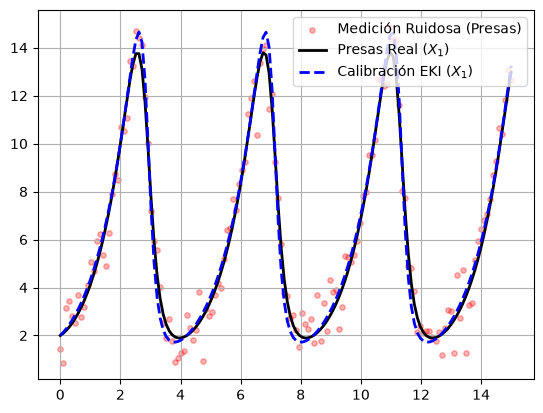

In [419]:
# IMPLEMENTACION DE RESAMPLED ENSEMBLED KALMAN INVERSION (REKI)
N_en = 20
N_ite = 10
param_dim = 4

S = np.zeros((param_dim, N_en))
S[0, :] = np.random.uniform(0.2, 5.0, N_en) # alpha
S[1, :] = np.random.uniform(0.01, 1.0, N_en) # beta
S[2, :] = np.random.uniform(0.01, 1.0, N_en) # delta
S[3, :] = np.random.uniform(0.5, 5.0, N_en) # gamma

Gamma = np.eye(Nt) * (sigma**2 / dt)

U = np.log(S)
R_var = sigma**2 / dt
alpha_step = 0.5  # Factor de relajación/suavizado

for ite in range(N_ite):
    X = np.zeros((Nt, N_en))
    for i in range(N_en):
        x_sim = F(x0, np.exp(U[:,i]))
        X[:, i] = x_sim[:, 0] # Solo las presas
        
    U_mean = np.mean(U, axis=1, keepdims=True)
    X_mean = np.mean(X, axis=1, keepdims=True)
    
    A_U = U - U_mean
    A_X = X - X_mean

    C_dual = (A_X.T @ A_X) + (N_en - 1) * R_var * np.eye(N_en)
    K = A_U @ np.linalg.inv(C_dual) @ A_X.T
    
    for i in range(N_en):
        y_pert = dY / dt + np.random.normal(0, np.sqrt(R_var), Nt)
        U[:, i] += alpha_step * (K @ (y_pert - X[:, i]))

    U_mean_vec = np.mean(U, axis=1)
    U_cov_mat = np.cov(U)

    # Inflación de varianza adaptativa
    inno = dY / dt - X_mean.T[0]
    var_inno = np.var(A_X, axis=1) + R_var
    lambda_inf = np.clip(np.mean(inno**2) / np.mean(var_inno), 1.0, 1.05)
    U_cov_inflated = lambda_inf * U_cov_mat + 1e-8 * np.eye(param_dim)
    
    U = np.random.multivariate_normal(U_mean_vec, U_cov_inflated, N_en).T
    
    error_rel = np.mean(inno**2) / np.mean((dY / dt)**2)
    print(f"Iteración: {ite+1:02d} -- Error medio Observación: {error_rel:.6f}")
    
U_est = np.mean(U, axis=1)
S_est = np.exp(U_est)
alpha_est, beta_est, delta_est, gamma_est = S_est

print("\n--> ¡EKI Terminado exitosamente!")
print(f"Alpha  -> Real: {alpha:<6} | Calibrado: {alpha_est:.4f}")
print(f"Beta   -> Real: {beta:<6} | Calibrado: {beta_est:.4f}")
print(f"Delta  -> Real: {delta:<6} | Calibrado: {delta_est:.4f}")
print(f"Gamma  -> Real: {gamma:<6} | Calibrado: {gamma_est:.4f}")

x_est = F(x0, S_est)
plt.scatter(time, dY / dt, color='red', alpha=0.3, s=15, label='Medición Ruidosa (Presas)')
plt.plot(time, X_real[:, 0], 'k-', lw=2, label='Presas Real ($X_1$)')
plt.plot(time, x_est[:, 0], 'b--', lw=2, label='Calibración EKI ($X_1$)')
plt.legend()
plt.grid()

Iteración: 01 -- Error medio Observación: 3.080163
Iteración: 02 -- Error medio Observación: 0.290499
Iteración: 03 -- Error medio Observación: 0.287485
Iteración: 04 -- Error medio Observación: 0.132656
Iteración: 05 -- Error medio Observación: 0.092455
Iteración: 06 -- Error medio Observación: 0.031599
Iteración: 07 -- Error medio Observación: 0.013746
Iteración: 08 -- Error medio Observación: 0.012163
Iteración: 09 -- Error medio Observación: 0.011832
Iteración: 10 -- Error medio Observación: 0.011641
Iteración: 11 -- Error medio Observación: 0.011483
Iteración: 12 -- Error medio Observación: 0.011436
Iteración: 13 -- Error medio Observación: 0.011400
Iteración: 14 -- Error medio Observación: 0.011383
Iteración: 15 -- Error medio Observación: 0.011358
Iteración: 16 -- Error medio Observación: 0.011350
Iteración: 17 -- Error medio Observación: 0.011332
Iteración: 18 -- Error medio Observación: 0.011328
Iteración: 19 -- Error medio Observación: 0.011325
Iteración: 20 -- Error medio Ob

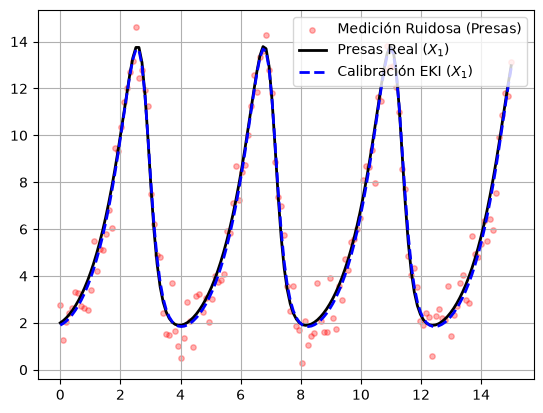

In [456]:
# IMPLEMENTACION DE RESAMPLED ENSEMBLED KALMAN INVERSION (REKI)
N_en = 50
N_ite = 20
param_dim = 6

S = np.zeros((param_dim, N_en))
S[0, :] = np.random.uniform(0.1, 5.0, N_en) # x01
S[1, :] = np.random.uniform(0.1, 5.0, N_en) # x02
S[2, :] = np.random.uniform(0.2, 5.0, N_en) # alpha
S[3, :] = np.random.uniform(0.01, 1.0, N_en) # beta
S[4, :] = np.random.uniform(0.01, 1.0, N_en) # delta
S[5, :] = np.random.uniform(0.5, 5.0, N_en) # gamma

Gamma = np.eye(Nt) * (sigma**2 / dt)

U = np.log(S)
R_var = sigma**2 / dt
alpha_step = 0.5  # Factor de relajación/suavizado

for ite in range(N_ite):
    X = np.zeros((Nt, N_en))
    for i in range(N_en):
        S_sim = np.exp(U[:,i])
        x0_sim = S_sim[:2]
        params_sim = S_sim[2:]
        x_sim = F(x0_sim, params_sim)
        X[:, i] = x_sim[:, 0] # Solo las presas
        
    U_mean = np.mean(U, axis=1, keepdims=True)
    X_mean = np.mean(X, axis=1, keepdims=True)
    
    A_U = U - U_mean
    A_X = X - X_mean

    C_dual = (A_X.T @ A_X) + (N_en - 1) * R_var * np.eye(N_en)
    K = A_U @ np.linalg.inv(C_dual) @ A_X.T
    
    for i in range(N_en):
        y_pert = dY / dt + np.random.normal(0, np.sqrt(R_var), Nt)
        U[:, i] += alpha_step * (K @ (y_pert - X[:, i]))

    U_mean_vec = np.mean(U, axis=1)
    U_cov_mat = np.cov(U)

    # Inflación de varianza adaptativa
    inno = dY / dt - X_mean.T[0]
    var_inno = np.var(A_X, axis=1) + R_var
    lambda_inf = np.clip(np.mean(inno**2) / np.mean(var_inno), 1.0, 1.1)
    U_cov_inflated = lambda_inf * U_cov_mat + 1e-8 * np.eye(param_dim)
    
    U = np.random.multivariate_normal(U_mean_vec, U_cov_inflated, N_en).T
    
    error_rel = np.mean(inno**2) / np.mean((dY / dt)**2)
    print(f"Iteración: {ite+1:02d} -- Error medio Observación: {error_rel:.6f}")
    
U_est = np.mean(U, axis=1)
S_est = np.exp(U_est)
x0_est = S_est[0], S_est[1]
params_est = S_est[2:]

x01_est, x02_est = x0_est
alpha_est, beta_est, delta_est, gamma_est = params_est

print("\n--> ¡EKI Terminado exitosamente!")
print(f"X01  -> Real: {x0[0]:<6} | Calibrado: {x01_est:.4f}")
print(f"X02  -> Real: {x0[1]:<6} | Calibrado: {x02_est:.4f}")
print(f"Alpha  -> Real: {alpha:<6} | Calibrado: {alpha_est:.4f}")
print(f"Beta   -> Real: {beta:<6} | Calibrado: {beta_est:.4f}")
print(f"Delta  -> Real: {delta:<6} | Calibrado: {delta_est:.4f}")
print(f"Gamma  -> Real: {gamma:<6} | Calibrado: {gamma_est:.4f}")

x_est = F(x0_est, params_est)
plt.scatter(time, dY / dt, color='red', alpha=0.3, s=15, label='Medición Ruidosa (Presas)')
plt.plot(time, X_real[:, 0], 'k-', lw=2, label='Presas Real ($X_1$)')
plt.plot(time, x_est[:, 0], 'b--', lw=2, label='Calibración EKI ($X_1$)')
plt.legend()
plt.grid()